# Physics-Informed Neural Networks for Urban Air Quality Modelling

## Predicting Pollutant Transport Using Advection–Diffusion–Reaction PDEs


This project explores the use of Physics-Informed Neural Networks (PINNs) for modelling urban air pollution dynamics.

The model integrates:

* Advection processes
* Diffusion mechanisms
* Reaction dynamics
* PDE residual minimisation
* Boundary and initial conditions

## Technologies Used

* Python
* PyTorch
* NumPy
* Matplotlib
* PINNs
* Scientific Machine Learning

## Research Focus

Urban Air Quality • PINNs • PDE-Constrained Learning • Environmental Modelling


In [2]:
#Install Required Libraries
!pip install torch numpy matplotlib

In [4]:
#Import Libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Select Device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [6]:
#Define the Neural Network
class PINN(nn.Module):

    def __init__(self):

        super(PINN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)

        )

    def forward(self, x, t):

        inputs = torch.cat([x, t], dim=1)

        return self.network(inputs)

In [7]:
#Create the Model
model = PINN().to(device)

In [8]:
#Define the Diffusion Coefficient
D = 0.01

In [9]:
#Generate Training Points
N = 1000

x = torch.rand((N,1), requires_grad=True).to(device)

t = torch.rand((N,1), requires_grad=True).to(device)

In [10]:
#Define PDE Residual Function
def pde_residual(model, x, t):

    C = model(x, t)

    # First derivative wrt time
    C_t = torch.autograd.grad(
        C,
        t,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    # First derivative wrt space
    C_x = torch.autograd.grad(
        C,
        x,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    # Second derivative wrt space
    C_xx = torch.autograd.grad(
        C_x,
        x,
        grad_outputs=torch.ones_like(C_x),
        create_graph=True
    )[0]

    # PDE residual
    residual = C_t - D * C_xx

    return residual

In [11]:
#Define Initial Conditions
N_ic = 200

x_ic = torch.rand((N_ic,1)).to(device)

t_ic = torch.zeros((N_ic,1)).to(device)

C_ic = torch.sin(np.pi * x_ic)

In [12]:
#Define the Loss Function
def loss_function():

    # PDE loss
    residual = pde_residual(model, x, t)

    pde_loss = torch.mean(residual**2)

    # Initial condition prediction
    C_pred = model(x_ic, t_ic)

    ic_loss = torch.mean((C_pred - C_ic)**2)

    total_loss = pde_loss + ic_loss

    return total_loss

In [13]:
#Define the Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [25]:
#Training Loop
epochs = 5000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    loss = loss_function()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:

        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.000002
Epoch 500, Loss: 0.000001
Epoch 1000, Loss: 0.000001
Epoch 1500, Loss: 0.000001
Epoch 2000, Loss: 0.000001
Epoch 2500, Loss: 0.000005
Epoch 3000, Loss: 0.000001
Epoch 3500, Loss: 0.000001
Epoch 4000, Loss: 0.000001
Epoch 4500, Loss: 0.000001


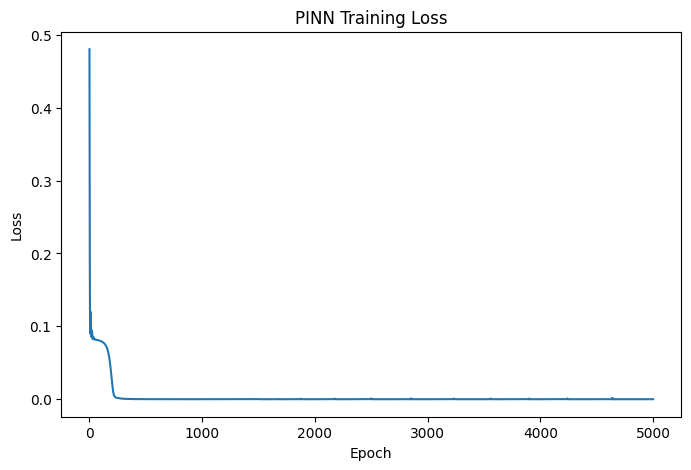

In [17]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("PINN Training Loss")

plt.show()

In [18]:
#Model Prediction
x_test = np.linspace(0,1,100)

t_test = np.ones_like(x_test) * 0.5

In [19]:
x_test_tensor = torch.tensor(
    x_test.reshape(-1,1),
    dtype=torch.float32
).to(device)

t_test_tensor = torch.tensor(
    t_test.reshape(-1,1),
    dtype=torch.float32
).to(device)

In [20]:
model.eval()

with torch.no_grad():

    C_pred = model(
        x_test_tensor,
        t_test_tensor
    ).cpu().numpy()

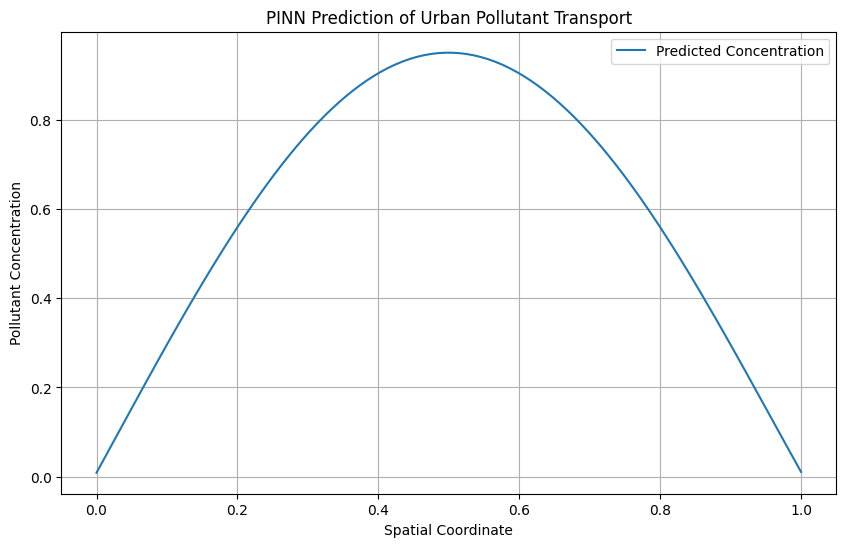

In [23]:
plt.figure(figsize=(10,6))

plt.plot(x_test, C_pred, label='Predicted Concentration')

plt.xlabel("Spatial Coordinate")
plt.ylabel("Pollutant Concentration")
plt.title("PINN Prediction of Urban Pollutant Transport")

plt.legend()
plt.grid(True)

plt.show()

In [27]:
#2D Diffiusion
class PINN2D(nn.Module):

    def __init__(self):

        super(PINN2D, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)

        )

    def forward(self, x, y, t):

        inputs = torch.cat([x, y, t], dim=1)

        return self.network(inputs)

In [28]:
model = PINN2D().to(device)

In [29]:
N = 5000

x = torch.rand((N,1), requires_grad=True).to(device)

y = torch.rand((N,1), requires_grad=True).to(device)

t = torch.rand((N,1), requires_grad=True).to(device)

In [30]:
def pde_residual_2d(model, x, y, t):

    C = model(x, y, t)

    # Time derivative
    C_t = torch.autograd.grad(
        C,
        t,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    # X derivatives
    C_x = torch.autograd.grad(
        C,
        x,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_xx = torch.autograd.grad(
        C_x,
        x,
        grad_outputs=torch.ones_like(C_x),
        create_graph=True
    )[0]

    # Y derivatives
    C_y = torch.autograd.grad(
        C,
        y,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_yy = torch.autograd.grad(
        C_y,
        y,
        grad_outputs=torch.ones_like(C_y),
        create_graph=True
    )[0]

    # Diffusion coefficient
    D = 0.01

    # 2D diffusion PDE
    residual = C_t - D * (C_xx + C_yy)

    return residual

In [31]:
N_ic = 1000

x_ic = torch.rand((N_ic,1)).to(device)

y_ic = torch.rand((N_ic,1)).to(device)

t_ic = torch.zeros((N_ic,1)).to(device)

# Gaussian pollution source
C_ic = torch.exp(
    -20 * (
        (x_ic - 0.5)**2 +
        (y_ic - 0.5)**2
    )
)

In [32]:
def loss_function():

    residual = pde_residual_2d(
        model,
        x,
        y,
        t
    )

    pde_loss = torch.mean(residual**2)

    C_pred = model(
        x_ic,
        y_ic,
        t_ic
    )

    ic_loss = torch.mean(
        (C_pred - C_ic)**2
    )

    total_loss = pde_loss + ic_loss

    return total_loss

In [33]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [34]:
epochs = 5000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    loss = loss_function()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch}, Loss: {loss.item():.6f}"
        )

Epoch 0, Loss: 0.091461
Epoch 500, Loss: 0.002623
Epoch 1000, Loss: 0.000273
Epoch 1500, Loss: 0.000132
Epoch 2000, Loss: 0.000082
Epoch 2500, Loss: 0.000081
Epoch 3000, Loss: 0.000043
Epoch 3500, Loss: 0.000032
Epoch 4000, Loss: 0.000025
Epoch 4500, Loss: 0.000020


In [35]:
x_vals = np.linspace(0,1,100)

y_vals = np.linspace(0,1,100)

X, Y = np.meshgrid(x_vals, y_vals)

In [36]:
t_vals = np.full_like(X, 0.5)

x_test = torch.tensor(
    X.flatten().reshape(-1,1),
    dtype=torch.float32
).to(device)

y_test = torch.tensor(
    Y.flatten().reshape(-1,1),
    dtype=torch.float32
).to(device)

t_test = torch.tensor(
    t_vals.flatten().reshape(-1,1),
    dtype=torch.float32
).to(device)

In [37]:
model.eval()

with torch.no_grad():

    C_pred = model(
        x_test,
        y_test,
        t_test
    ).cpu().numpy()

In [38]:
C_pred = C_pred.reshape(X.shape)

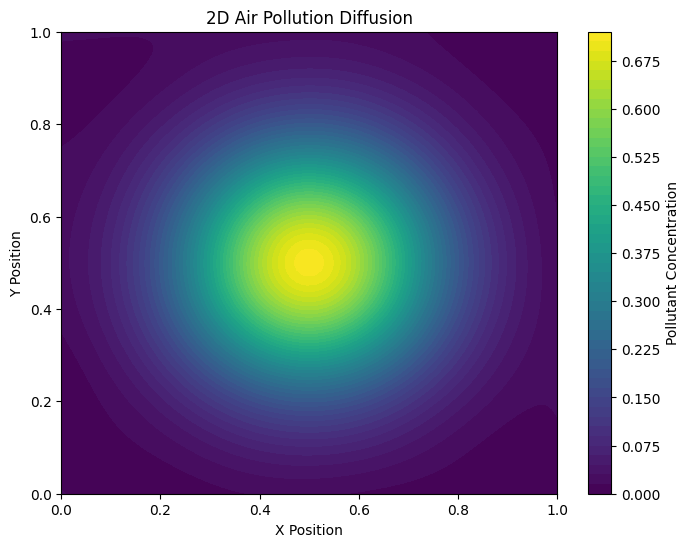

In [39]:
plt.figure(figsize=(8,6))

plt.contourf(
    X,
    Y,
    C_pred,
    levels=50
)

plt.colorbar(
    label="Pollutant Concentration"
)

plt.xlabel("X Position")

plt.ylabel("Y Position")

plt.title("2D Air Pollution Diffusion")

plt.show()

Using device: cpu
Epoch 0, Loss: 0.059727
Epoch 500, Loss: 0.007869
Epoch 1000, Loss: 0.000421
Epoch 1500, Loss: 0.000158
Epoch 2000, Loss: 0.000114
Epoch 2500, Loss: 0.000074
Epoch 3000, Loss: 0.000059
Epoch 3500, Loss: 0.000048
Epoch 4000, Loss: 0.000040
Epoch 4500, Loss: 0.000046


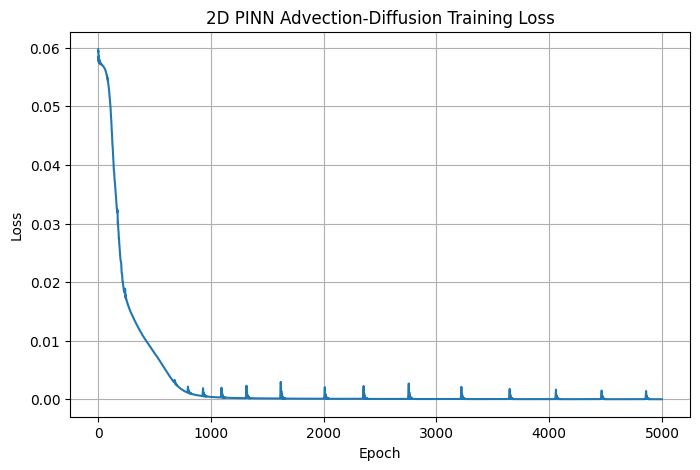

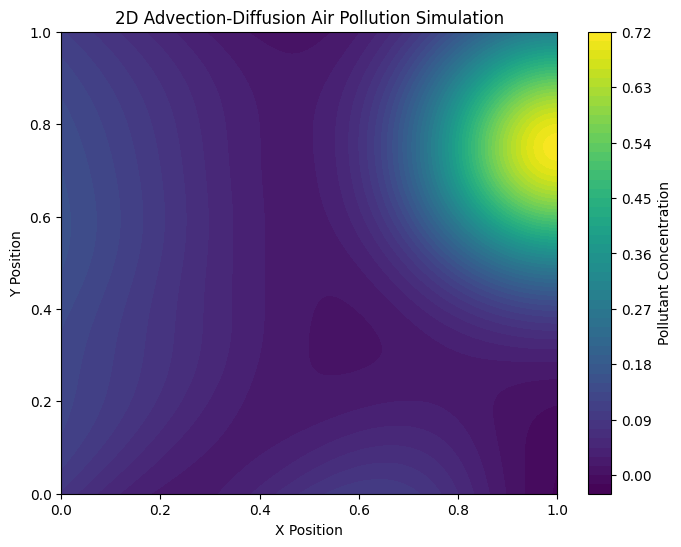

In [40]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Device
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# ==========================================
# 2D PINN Model
# ==========================================

class PINN2D(nn.Module):

    def __init__(self):

        super(PINN2D, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)

        )

    def forward(self, x, y, t):

        inputs = torch.cat([x, y, t], dim=1)

        return self.network(inputs)

# ==========================================
# Create Model
# ==========================================

model = PINN2D().to(device)

# ==========================================
# Training Points
# ==========================================

N = 5000

x = torch.rand((N,1), requires_grad=True).to(device)

y = torch.rand((N,1), requires_grad=True).to(device)

t = torch.rand((N,1), requires_grad=True).to(device)

# ==========================================
# Initial Condition
# ==========================================

N_ic = 1000

x_ic = torch.rand((N_ic,1)).to(device)

y_ic = torch.rand((N_ic,1)).to(device)

t_ic = torch.zeros((N_ic,1)).to(device)

# Gaussian pollution source at center

C_ic = torch.exp(
    -20 * (
        (x_ic - 0.5)**2 +
        (y_ic - 0.5)**2
    )
)

# ==========================================
# PDE Residual (2D Advection-Diffusion)
# ==========================================

def pde_residual_2d_adv(model, x, y, t):

    # Network prediction
    C = model(x, y, t)

    # ======================================
    # Time derivative
    # ======================================

    C_t = torch.autograd.grad(
        C,
        t,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    # ======================================
    # X derivatives
    # ======================================

    C_x = torch.autograd.grad(
        C,
        x,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_xx = torch.autograd.grad(
        C_x,
        x,
        grad_outputs=torch.ones_like(C_x),
        create_graph=True
    )[0]

    # ======================================
    # Y derivatives
    # ======================================

    C_y = torch.autograd.grad(
        C,
        y,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_yy = torch.autograd.grad(
        C_y,
        y,
        grad_outputs=torch.ones_like(C_y),
        create_graph=True
    )[0]

    # ======================================
    # Physical Parameters
    # ======================================

    D = 0.01

    # Wind velocities
    u = 1.0
    v = 0.5

    # ======================================
    # Advection-Diffusion PDE
    # ======================================

    residual = (
        C_t
        + u * C_x
        + v * C_y
        - D * (C_xx + C_yy)
    )

    return residual

# ==========================================
# Loss Function
# ==========================================

def loss_function():

    # PDE loss
    residual = pde_residual_2d_adv(
        model,
        x,
        y,
        t
    )

    pde_loss = torch.mean(residual**2)

    # Initial condition loss
    C_pred = model(
        x_ic,
        y_ic,
        t_ic
    )

    ic_loss = torch.mean(
        (C_pred - C_ic)**2
    )

    # Total loss
    total_loss = pde_loss + ic_loss

    return total_loss

# ==========================================
# Optimizer
# ==========================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# ==========================================
# Training
# ==========================================

epochs = 5000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    loss = loss_function()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch}, Loss: {loss.item():.6f}"
        )

# ==========================================
# Plot Training Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("2D PINN Advection-Diffusion Training Loss")

plt.grid(True)

plt.show()

# ==========================================
# Create Grid for Visualization
# ==========================================

x_vals = np.linspace(0,1,100)

y_vals = np.linspace(0,1,100)

X, Y = np.meshgrid(x_vals, y_vals)

# Fixed time snapshot
t_snapshot = 0.5

T = np.full_like(X, t_snapshot)

# ==========================================
# Convert to Tensors
# ==========================================

x_test = torch.tensor(
    X.flatten().reshape(-1,1),
    dtype=torch.float32
).to(device)

y_test = torch.tensor(
    Y.flatten().reshape(-1,1),
    dtype=torch.float32
).to(device)

t_test = torch.tensor(
    T.flatten().reshape(-1,1),
    dtype=torch.float32
).to(device)

# ==========================================
# Predict Concentration Field
# ==========================================

model.eval()

with torch.no_grad():

    C_pred = model(
        x_test,
        y_test,
        t_test
    ).cpu().numpy()

# Reshape predictions

C_pred = C_pred.reshape(X.shape)

# ==========================================
# Plot Heatmap
# ==========================================

plt.figure(figsize=(8,6))

contour = plt.contourf(
    X,
    Y,
    C_pred,
    levels=50
)

plt.colorbar(
    contour,
    label="Pollutant Concentration"
)

plt.xlabel("X Position")

plt.ylabel("Y Position")

plt.title("2D Advection-Diffusion Air Pollution Simulation")

plt.show()

In [ ]:
# ==========================================
# Boundary Condition Points
# ==========================================

N_bc = 1000

# Random time values
t_bc = torch.rand((N_bc,1)).to(device)

# ==========================================
# Left Boundary (x = 0)
# ==========================================

x_left = torch.zeros((N_bc,1)).to(device)

y_left = torch.rand((N_bc,1)).to(device)

C_left = torch.zeros((N_bc,1)).to(device)

# ==========================================
# Right Boundary (x = 1)
# ==========================================

x_right = torch.ones((N_bc,1)).to(device)

y_right = torch.rand((N_bc,1)).to(device)

C_right = torch.zeros((N_bc,1)).to(device)

# ==========================================
# Bottom Boundary (y = 0)
# ==========================================

x_bottom = torch.rand((N_bc,1)).to(device)

y_bottom = torch.zeros((N_bc,1)).to(device)

C_bottom = torch.zeros((N_bc,1)).to(device)

# ==========================================
# Top Boundary (y = 1)
# ==========================================

x_top = torch.rand((N_bc,1)).to(device)

y_top = torch.ones((N_bc,1)).to(device)

C_top = torch.zeros((N_bc,1)).to(device)

In [ ]:
# ==========================================
# Updated Loss Function
# ==========================================

def loss_function():

    # ======================================
    # PDE Loss
    # ======================================

    residual = pde_residual_2d_adv(
        model,
        x,
        y,
        t
    )

    pde_loss = torch.mean(residual**2)

    # ======================================
    # Initial Condition Loss
    # ======================================

    C_pred_ic = model(
        x_ic,
        y_ic,
        t_ic
    )

    ic_loss = torch.mean(
        (C_pred_ic - C_ic)**2
    )

    # ======================================
    # Boundary Condition Loss
    # ======================================

    # Left
    pred_left = model(
        x_left,
        y_left,
        t_bc
    )

    loss_left = torch.mean(
        (pred_left - C_left)**2
    )

    # Right
    pred_right = model(
        x_right,
        y_right,
        t_bc
    )

    loss_right = torch.mean(
        (pred_right - C_right)**2
    )

    # Bottom
    pred_bottom = model(
        x_bottom,
        y_bottom,
        t_bc
    )

    loss_bottom = torch.mean(
        (pred_bottom - C_bottom)**2
    )

    # Top
    pred_top = model(
        x_top,
        y_top,
        t_bc
    )

    loss_top = torch.mean(
        (pred_top - C_top)**2
    )

    # Total BC loss
    bc_loss = (
        loss_left
        + loss_right
        + loss_bottom
        + loss_top
    )

    # ======================================
    # Total Loss
    # ======================================

    total_loss = (
        pde_loss
        + ic_loss
        + bc_loss
    )

    return total_loss

In [ ]:
# ==========================================
# Retraining
# ==========================================

epochs = 5000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    loss = loss_function()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch}, Loss: {loss.item():.6f}"
        )

Epoch 0, Loss: 0.055728
Epoch 500, Loss: 0.024930
Epoch 1000, Loss: 0.024751
Epoch 1500, Loss: 0.024626
Epoch 2000, Loss: 0.024528
Epoch 2500, Loss: 0.024452
Epoch 3000, Loss: 0.024388
Epoch 3500, Loss: 0.024322
Epoch 4000, Loss: 0.024712
Epoch 4500, Loss: 0.024252


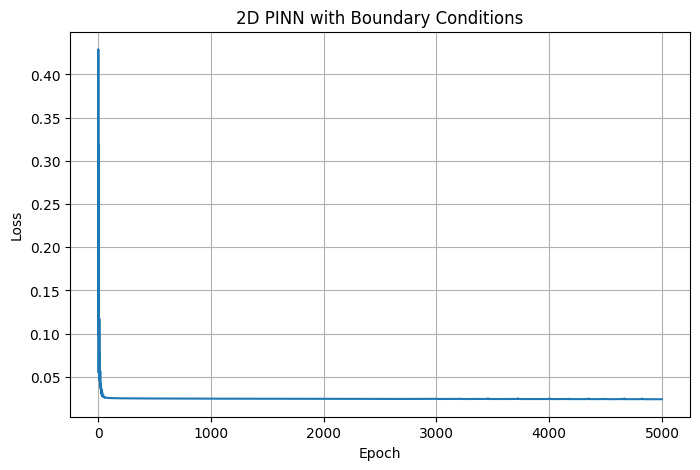

In [ ]:
# ==========================================
# Plot Training Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("2D PINN with Boundary Conditions")

plt.grid(True)

plt.show()

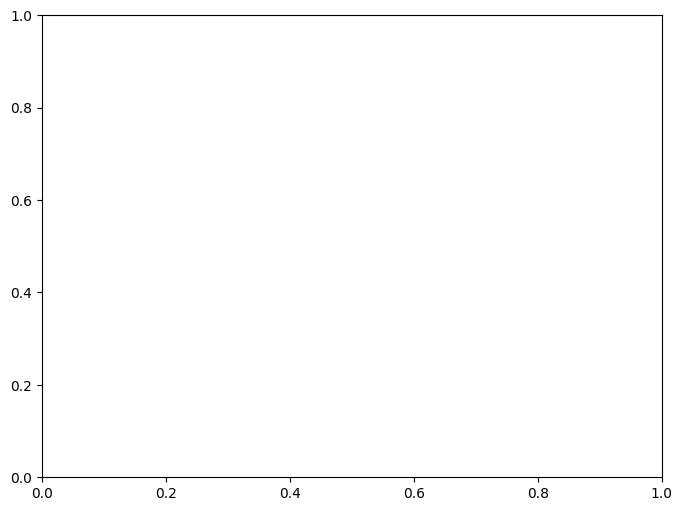

In [ ]:
from matplotlib.animation import FuncAnimation

# ==========================================
# Create Figure
# ==========================================

fig, ax = plt.subplots(figsize=(8,6))

# ==========================================
# Animation Function
# ==========================================

def animate(frame):

    ax.clear()

    # Time value
    t_snapshot = frame / 20

    # Create grid
    x_vals = np.linspace(0,1,100)

    y_vals = np.linspace(0,1,100)

    X, Y = np.meshgrid(
        x_vals,
        y_vals
    )

    T = np.full_like(
        X,
        t_snapshot
    )

    # Convert to tensors
    x_test = torch.tensor(
        X.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    y_test = torch.tensor(
        Y.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    t_test = torch.tensor(
        T.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    # Predict
    model.eval()

    with torch.no_grad():

        C_pred = model(
            x_test,
            y_test,
            t_test
        ).cpu().numpy()

    # Reshape
    C_pred = C_pred.reshape(X.shape)

    # Plot
    contour = ax.contourf(
        X,
        Y,
        C_pred,
        levels=50
    )

    ax.set_title(
        f"2D Advection-Diffusion\nTime = {t_snapshot:.2f}"
    )

    ax.set_xlabel("X Position")

    ax.set_ylabel("Y Position")

# ==========================================
# Run Animation
# ==========================================

anim = FuncAnimation(
    fig,
    animate,
    frames=20,
    interval=300
)

plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


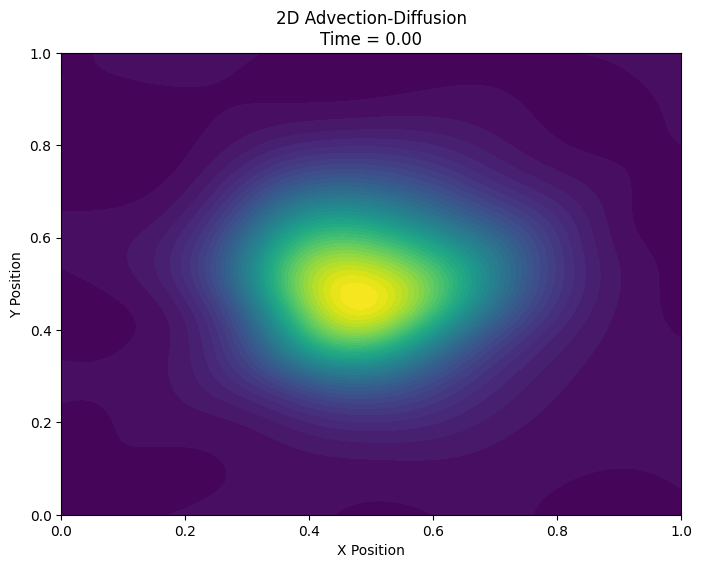

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==========================================
# Create Figure
# ==========================================

fig, ax = plt.subplots(figsize=(8,6))

# ==========================================
# Animation Function
# ==========================================

def animate(frame):

    ax.clear()

    # Time value
    t_snapshot = frame / 20

    # Create grid
    x_vals = np.linspace(0,1,100)

    y_vals = np.linspace(0,1,100)

    X, Y = np.meshgrid(
        x_vals,
        y_vals
    )

    T = np.full_like(
        X,
        t_snapshot
    )

    # Convert to tensors
    x_test = torch.tensor(
        X.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    y_test = torch.tensor(
        Y.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    t_test = torch.tensor(
        T.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    # Predict
    model.eval()

    with torch.no_grad():

        C_pred = model(
            x_test,
            y_test,
            t_test
        ).cpu().numpy()

    # Reshape predictions
    C_pred = C_pred.reshape(X.shape)

    # Plot heatmap
    contour = ax.contourf(
        X,
        Y,
        C_pred,
        levels=50,
        cmap='viridis'
    )

    ax.set_title(
        f"2D Advection-Diffusion\nTime = {t_snapshot:.2f}"
    )

    ax.set_xlabel("X Position")

    ax.set_ylabel("Y Position")

# ==========================================
# Create Animation
# ==========================================

anim = FuncAnimation(
    fig,
    animate,
    frames=20,
    interval=300
)

# ==========================================
# Display Animation
# ==========================================

HTML(anim.to_jshtml())

In [ ]:
# ==========================================
# 2D Advection-Diffusion-Reaction PINN
# ==========================================

def pde_residual_2d_reactive(model, x, y, t):

    # ======================================
    # Network Prediction
    # ======================================

    C = model(x, y, t)

    # ======================================
    # Time Derivative
    # ======================================

    C_t = torch.autograd.grad(
        C,
        t,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    # ======================================
    # X Derivatives
    # ======================================

    C_x = torch.autograd.grad(
        C,
        x,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_xx = torch.autograd.grad(
        C_x,
        x,
        grad_outputs=torch.ones_like(C_x),
        create_graph=True
    )[0]

    # ======================================
    # Y Derivatives
    # ======================================

    C_y = torch.autograd.grad(
        C,
        y,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_yy = torch.autograd.grad(
        C_y,
        y,
        grad_outputs=torch.ones_like(C_y),
        create_graph=True
    )[0]

    # ======================================
    # Physical Parameters
    # ======================================

    D = 0.01

    # Wind velocities
    u = 1.0
    v = 0.5

    # Pollutant decay coefficient
    k = 0.5

    # ======================================
    # Reactive Advection-Diffusion PDE
    # ======================================

    residual = (
        C_t
        + u * C_x
        + v * C_y
        - D * (C_xx + C_yy)
        + k * C
    )

    return residual

Using device: cpu
Epoch 0, Loss: 0.139104
Epoch 500, Loss: 0.041780
Epoch 1000, Loss: 0.022848
Epoch 1500, Loss: 0.019877
Epoch 2000, Loss: 0.019042
Epoch 2500, Loss: 0.018778
Epoch 3000, Loss: 0.018633
Epoch 3500, Loss: 0.018912
Epoch 4000, Loss: 0.018484
Epoch 4500, Loss: 0.018433


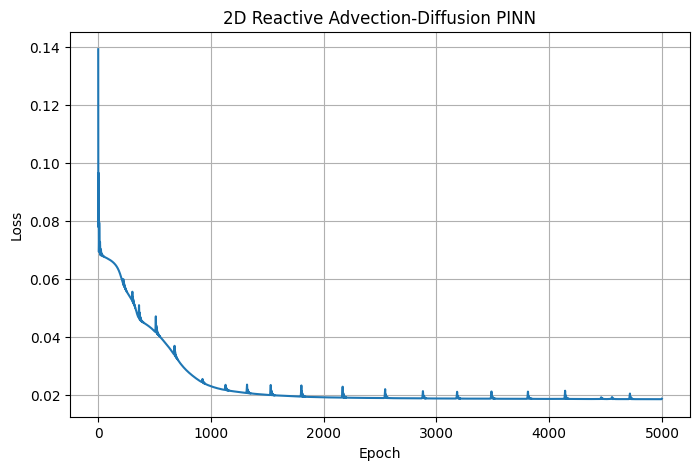

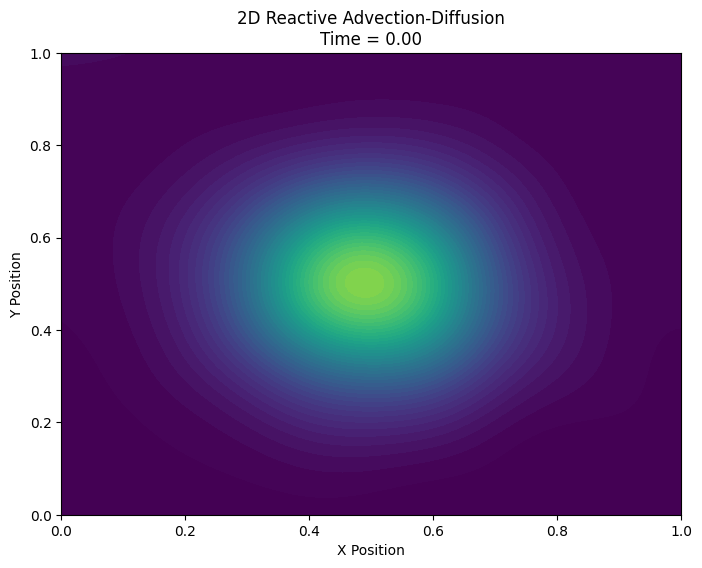

In [41]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==========================================
# Device
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# ==========================================
# 2D PINN Model
# ==========================================

class PINN2D(nn.Module):

    def __init__(self):

        super(PINN2D, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)

        )

    def forward(self, x, y, t):

        inputs = torch.cat([x, y, t], dim=1)

        return self.network(inputs)

# ==========================================
# Create Model
# ==========================================

model = PINN2D().to(device)

# ==========================================
# Training Points
# ==========================================

N = 5000

x = torch.rand((N,1), requires_grad=True).to(device)

y = torch.rand((N,1), requires_grad=True).to(device)

t = torch.rand((N,1), requires_grad=True).to(device)

# ==========================================
# Initial Condition
# ==========================================

N_ic = 1000

x_ic = torch.rand((N_ic,1)).to(device)

y_ic = torch.rand((N_ic,1)).to(device)

t_ic = torch.zeros((N_ic,1)).to(device)

# Gaussian pollution source

C_ic = torch.exp(
    -20 * (
        (x_ic - 0.5)**2 +
        (y_ic - 0.5)**2
    )
)

# ==========================================
# Boundary Conditions
# ==========================================

N_bc = 1000

t_bc = torch.rand((N_bc,1)).to(device)

# Left boundary
x_left = torch.zeros((N_bc,1)).to(device)
y_left = torch.rand((N_bc,1)).to(device)

# Right boundary
x_right = torch.ones((N_bc,1)).to(device)
y_right = torch.rand((N_bc,1)).to(device)

# Bottom boundary
x_bottom = torch.rand((N_bc,1)).to(device)
y_bottom = torch.zeros((N_bc,1)).to(device)

# Top boundary
x_top = torch.rand((N_bc,1)).to(device)
y_top = torch.ones((N_bc,1)).to(device)

# ==========================================
# PDE Residual
# 2D Advection-Diffusion-Reaction
# ==========================================

def pde_residual_2d_reactive(model, x, y, t):

    # Network prediction
    C = model(x, y, t)

    # ======================================
    # Time derivative
    # ======================================

    C_t = torch.autograd.grad(
        C,
        t,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    # ======================================
    # X derivatives
    # ======================================

    C_x = torch.autograd.grad(
        C,
        x,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_xx = torch.autograd.grad(
        C_x,
        x,
        grad_outputs=torch.ones_like(C_x),
        create_graph=True
    )[0]

    # ======================================
    # Y derivatives
    # ======================================

    C_y = torch.autograd.grad(
        C,
        y,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    C_yy = torch.autograd.grad(
        C_y,
        y,
        grad_outputs=torch.ones_like(C_y),
        create_graph=True
    )[0]

    # ======================================
    # Physical Parameters
    # ======================================

    D = 0.01

    # Wind velocities
    u = 1.0
    v = 0.5

    # Pollutant decay coefficient
    k = 0.5

    # ======================================
    # Advection-Diffusion-Reaction PDE
    # ======================================

    residual = (
        C_t
        + u * C_x
        + v * C_y
        - D * (C_xx + C_yy)
        + k * C
    )

    return residual

# ==========================================
# Loss Function
# ==========================================

def loss_function():

    # ======================================
    # PDE Loss
    # ======================================

    residual = pde_residual_2d_reactive(
        model,
        x,
        y,
        t
    )

    pde_loss = torch.mean(residual**2)

    # ======================================
    # Initial Condition Loss
    # ======================================

    C_pred_ic = model(
        x_ic,
        y_ic,
        t_ic
    )

    ic_loss = torch.mean(
        (C_pred_ic - C_ic)**2
    )

    # ======================================
    # Boundary Condition Loss
    # ======================================

    pred_left = model(
        x_left,
        y_left,
        t_bc
    )

    pred_right = model(
        x_right,
        y_right,
        t_bc
    )

    pred_bottom = model(
        x_bottom,
        y_bottom,
        t_bc
    )

    pred_top = model(
        x_top,
        y_top,
        t_bc
    )

    bc_loss = (
        torch.mean(pred_left**2)
        + torch.mean(pred_right**2)
        + torch.mean(pred_bottom**2)
        + torch.mean(pred_top**2)
    )

    # ======================================
    # Total Loss
    # ======================================

    total_loss = (
        pde_loss
        + ic_loss
        + bc_loss
    )

    return total_loss

# ==========================================
# Optimizer
# ==========================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# ==========================================
# Training
# ==========================================

epochs = 5000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    loss = loss_function()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch}, Loss: {loss.item():.6f}"
        )

# ==========================================
# Plot Training Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("2D Reactive Advection-Diffusion PINN")

plt.grid(True)

plt.show()

# ==========================================
# Animation Setup
# ==========================================

fig, ax = plt.subplots(figsize=(8,6))

# ==========================================
# Animation Function
# ==========================================

def animate(frame):

    ax.clear()

    # Time snapshot
    t_snapshot = frame / 20

    # Grid
    x_vals = np.linspace(0,1,100)

    y_vals = np.linspace(0,1,100)

    X, Y = np.meshgrid(
        x_vals,
        y_vals
    )

    T = np.full_like(
        X,
        t_snapshot
    )

    # Convert to tensors
    x_test = torch.tensor(
        X.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    y_test = torch.tensor(
        Y.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    t_test = torch.tensor(
        T.flatten().reshape(-1,1),
        dtype=torch.float32
    ).to(device)

    # Predict
    model.eval()

    with torch.no_grad():

        C_pred = model(
            x_test,
            y_test,
            t_test
        ).cpu().numpy()

    # Reshape predictions
    C_pred = C_pred.reshape(X.shape)

    # Plot heatmap
    contour = ax.contourf(
        X,
        Y,
        C_pred,
        levels=50,
        cmap='viridis',
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"2D Reactive Advection-Diffusion\nTime = {t_snapshot:.2f}"
    )

    ax.set_xlabel("X Position")

    ax.set_ylabel("Y Position")

# ==========================================
# Create Animation
# ==========================================

anim = FuncAnimation(
    fig,
    animate,
    frames=20,
    interval=300
)

# ==========================================
# Display Animation
# ==========================================

HTML(anim.to_jshtml())

# Conclusions

This project demonstrated the application of Physics-Informed Neural Networks (PINNs) for modelling urban air quality dynamics using advection–diffusion–reaction partial differential equations.

The notebook integrated:

* scientific machine learning,
* PDE-constrained optimisation,
* automatic differentiation,
* and scientific visualisation techniques.

The results illustrate how neural networks can approximate physically consistent pollutant transport dynamics while satisfying governing equations and boundary constraints.

Future work may include:

* two-dimensional PDE systems,
* real environmental datasets,
* uncertainty quantification,
* and hybrid physics-data driven modelling approaches.
